# Test 5: Hybrid System

In [1]:
import sys
from typing import Any, Dict, Optional
from pathlib import Path

import numpy as np

from SysSimX.core.base import CoSimComponent
from SysSimX.core.port import PortSpec, PortType
from SysSimX.core.events import Event

from SysSimX.system.connection import EventConnection
from SysSimX.system.system import System

from SysSimX.components.fmu_comp import FMUComponent

from SysSimX.utilities.units import Quantity

from SysSimX.viz.sysgraph import SystemGraphVisualizer

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import docs.plot_setup as plot_setup
plt = plot_setup.set_professional_style()

----------------------

### Case 1: Non-Overlapping Events

- In this test case, we create a hybrid system where two events occur at different times.
- We verify that the hybrid algorithm correctly detects and handles each event in sequence without any conflicts.
- Two different event sources will trigger events at distinct times. Each event will trigger the same event handler that modifies the same state variable in the listener component.
- Sources and listeners evolve liearly over time. The velocity of the listener component is inverted at a discrete event that is causes by one of the source components.

```python
class HybridSource(CoSimComponent):
    """
    Simple component with a state variable that evolves linearly.
    x(t) = x0 + v * (t - t0)    
    """
    def __init__(self, name: str, x0: float = -1.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group='Sources')
        self.x0 = x0; self.v = v; self.t0 = t0
        
    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0
        self.output_specs.update({"x": PortSpec(name="x", 
                                                type=PortType.REAL,
                                                direction="out")})
        
    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)
    
    def snapshot_state(self):
        return {"t": self.t, "x": self.x, "v": self.v, "t0": self.t0}

    def restore_state(self, snapshot) -> None:
        self.t  = snapshot["t"]
        self.t0 = snapshot["t0"]
        self.x  = snapshot["x"]
        self.v  = snapshot["v"]

class HybridListener(CoSimComponent):
    """
    Simple component with a state variable that evolves linearly.
    x(t) = x0 + v * (t - t0)    
    """
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Listener")
        self.x0 = x0; self.v = v; self.t0 = t0
        
    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0
        self.output_specs.update({"x": PortSpec(name="x",
                                                type=PortType.REAL,
                                                direction="out")})
        self.input_specs.update({"v_invert": PortSpec(name="v_invert",
                                                      type=PortType.EVENT,
                                                      direction="in")})             
    
    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)

    def _handle_events_internal(self, event_names, t):
        if 'Trigger_1' in event_names or 'Trigger_2' in event_names:
            self.t0 = t
            self.x0 = self.x
            self.v = -self.v

```
-------------

In [2]:
class HybridSource(CoSimComponent):
    """
    Simple component with a state variable that evolves linearly.
    x(t) = x0 + v * (t - t0)    
    """
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group='Sources')
        self.x0 = x0; self.v = v; self.t0 = t0
        
    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0
        self.output_specs.update({
            "x": PortSpec(name="x", 
                          type=PortType.REAL,
                          direction="out"),
        })
        self._initialize_ports_from_specs()
        
    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)
        
    def _update_output_states(self, t: Optional[float]=None) -> None:
        self.outputs["x"].set(self.x, t=t)
        
    def set_state(self, state: Dict[str, Any], t: float) -> None:
        if "x" in state:
            val = state["x"]
            self.x = val.magnitude if isinstance(val, Quantity) else val
            
    def get_state(self) -> Dict[str, Any]:
        return {"x": self.x}
    
    def snapshot_state(self):
        return {"t": self.t, "x": self.x, "v": self.v, "t0": self.t0}

    def restore_state(self, snapshot) -> None:
        self.t  = snapshot["t"]
        self.t0 = snapshot["t0"]
        self.x  = snapshot["x"]
        self.v  = snapshot["v"]
    
    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self.inputs.clear()
        self.outputs.clear()

In [3]:
class HybridListener(CoSimComponent):
    """
    Simple component with a state variable that evolves linearly.
    x(t) = x0 + v * (t - t0)    
    """
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Listener")
        self.x0 = x0; self.v = v; self.t0 = t0
        
    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0
        self.output_specs.update({"x": PortSpec(name="x",
                                                type=PortType.REAL,
                                                direction="out")})
        self.input_specs.update({"v_invert": PortSpec(name="v_invert",
                                                      type=PortType.EVENT,
                                                      direction="in")})  
        self._initialize_ports_from_specs()
        
    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)
        
    def _update_output_states(self, t: Optional[float]=None) -> None:
        self.outputs["x"].set(self.x, t=t)
        
    def set_state(self, state: Dict[str, Any], t: float) -> None:
        if "x" in state:
            val = state["x"]
            self.x = val.magnitude if isinstance(val, Quantity) else val
            
    def get_state(self) -> Dict[str, Any]:
        return {"x": self.x}
    

    def _handle_events_internal(self, event_names, t):
        if 'Trigger_1' in event_names or 'Trigger_2' in event_names:
            self.t0 = t
            self.x0 = self.x
            self.v = -self.v
            print(f"{self.name} handled event at t={t:.4f}: v inverted from { -self.v } to { self.v }")
    
    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self._t0 = None
        self.inputs = {}
        self.outputs = {}


Component Classification:
 - event_sources: ['Source_1', 'Source_2']
 - event_listeners: ['Listener']
 - continuous_only: []

Using Algorithm: Hybrid-Algorithm



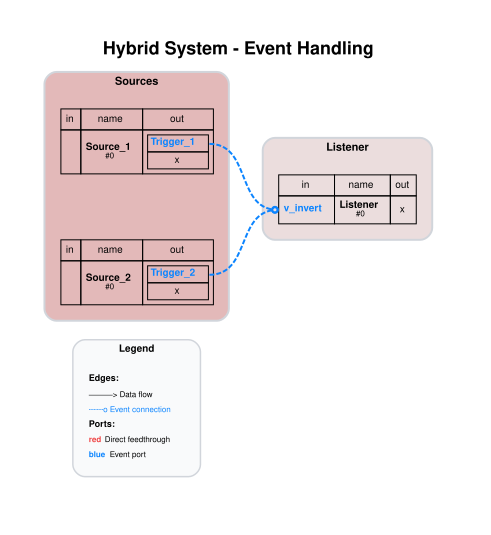

Starting hybrid co-simulation...


Events detected in interval [0.30000000, 0.35000000]
Events: [('Source_1', 'Trigger_1')]
Located at t=(0.33333334, 0)

Handling events at (0.33333334, 0): [('Source_1', 'Trigger_1')]

Events grouped by component for handling: {'Listener': ['Trigger_1']}

Dispatching event 'Trigger_1' from 'Source_1' to targets: ['Listener']
Listener handled event at t=0.3333: v inverted from 3.0 to -3.0


Events detected in interval [0.65000000, 0.70000000]
Events: [('Source_2', 'Trigger_2')]
Located at t=(0.66666667, 0)

Handling events at (0.66666667, 0): [('Source_2', 'Trigger_2')]

Events grouped by component for handling: {'Listener': ['Trigger_2']}

Dispatching event 'Trigger_2' from 'Source_2' to targets: ['Listener']
Listener handled event at t=0.6667: v inverted from -3.0 to 3.0



In [4]:
# 1) Create components
src_comp_1 = HybridSource(name="Source_1", x0=-2/3, v=2)
src_comp_2 = HybridSource(name="Source_2", x0=2/3,  v=-1)
listener_comp = HybridListener(name="Listener", x0=0.0,  v=3.0)

# 2) Define event indicator functions
def event_indicator_function(comp: HybridSource) -> float:
    return comp.x

# 3) Create events
event_1 = Event(name="Trigger_1", source=src_comp_1.name, direction=1)
event_2 = Event(name="Trigger_2", source=src_comp_2.name, direction=-1)

# 4) Initialize event source components
src_comp_1.initialize(t0=0.0)
src_comp_2.initialize(t0=0.0)

# 5) Add event indicators to source components
src_comp_1.add_event_indicator(name=event_1.name,
                               func=event_indicator_function,
                               direction=event_1.direction)
src_comp_2.add_event_indicator(name=event_2.name,
                               func=event_indicator_function,
                               direction=event_2.direction)

# 6) Initialize listener component and subscribe to events
listener_comp.initialize(t0=0.0)
listener_comp.subscribe_event(event=event_1)
listener_comp.subscribe_event(event=event_2)

# 7) Create system
system = System(name="Hybrid System - Event Handling")

# 8) Add components to system
system.add_component(src_comp_1)
system.add_component(src_comp_2)
system.add_component(listener_comp)

# 9) Create and add event connections to the system
connection_1 = EventConnection(src_comp=src_comp_1.name,
                               src_port=src_comp_1.output_specs['Trigger_1'].name,
                               dst_comp=listener_comp.name,
                               dst_port=listener_comp.input_specs['v_invert'].name)
connection_2 = EventConnection(src_comp=src_comp_2.name,
                               src_port=src_comp_2.output_specs['Trigger_2'].name,
                               dst_comp=listener_comp.name,
                               dst_port=listener_comp.input_specs['v_invert'].name)
system.add_event_connection(connection_1)
system.add_event_connection(connection_2)

# 10) Initialize and run the system
system.initialize(t0=0.0)

# 11) Component classification
print("\nComponent Classification:")
for classification, components in system.classify_components().items():
    print(f" - {classification}: {[component.name for component in components]}")

print(f"\nUsing Algorithm: {system.algorithm.name}\n")

# 11) Visualize the system graph
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

# 12) Run the simulation
print("Starting hybrid co-simulation...\n")
system.run(t0=0.0, tf=1.0, dt = 0.05)

In [5]:
time_src_1, data_src_1 = src_comp_1.get_history_arrays()
x_src_1 = data_src_1['x']

time_src_2, data_src_2 = src_comp_2.get_history_arrays()
x_src_2 = data_src_2['x']

time_listener, data_listener = listener_comp.get_history_arrays()
x_listener = data_listener['x']

event_history = system.history.get_all_event_histories()
trigger_times_1 = event_history.get((src_comp_1.name, 'Trigger_1'), [])
trigger_times_2 = event_history.get((src_comp_2.name, 'Trigger_2'), [])

trigger_time_1 = trigger_times_1[0].t
trigger_time_2 = trigger_times_2[0].t

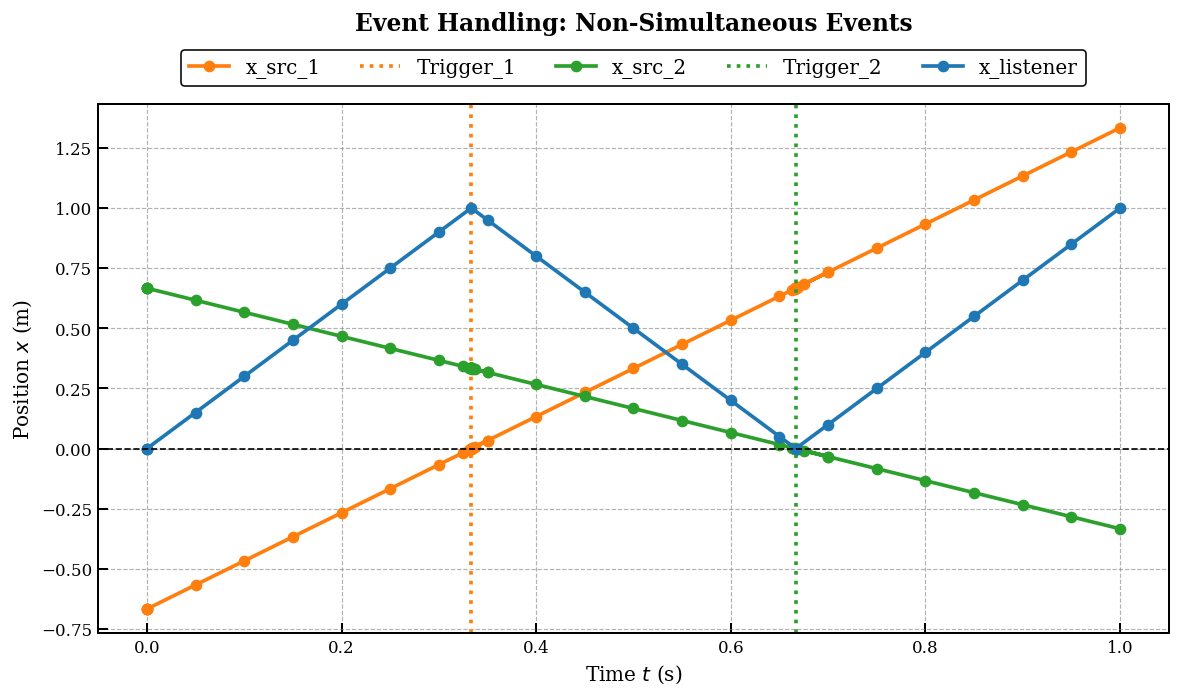

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(time_src_1, x_src_1, label='x_src_1', color='tab:orange', marker='o', linestyle='-')
plt.axvline(trigger_time_1, color='tab:orange', linestyle=':', label='Trigger_1')
plt.plot(time_src_2, x_src_2, label='x_src_2', color='tab:green', marker='o', linestyle='-')
plt.axvline(trigger_time_2, color='tab:green', linestyle=':', label='Trigger_2')
plt.plot(time_listener, x_listener, label='x_listener', color='tab:blue', marker='o', linestyle='-')
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title('Event Handling: Non-Simultaneous Events', fontsize=14, fontweight='bold', y= 1.12)
plt.xlabel('Time $t$ (s)')
plt.ylabel('Position $x$ (m)')
plt.grid()
plt.legend(loc='upper center', ncol=5, bbox_to_anchor=(0.5, 1.12))
plt.tight_layout()
plt.savefig('../figures/Hybrid/test_5_event_handling_1.svg')
plt.show()

- Both event sources are involved in the bisection process to localize the event time.
- Trigger_1 caused by the zero-crossing of Source_1 occurs first, followed by Trigger_2 caused by Source_2.
- The trigger times occur at $t_1 = 0.33334 \, s$ and $t_2 = 0.66667 \, s$, respectively.
- The listener component is advanced to each event time, and its velocity is inverted at each event.

-------------------

## Case 2: Event Chain

- In this test case, we create a hybrid system where a first event triggers a second event at the same real time instant.
- We introduce the concept of Dense Time, where multiple events can occur at the same real time but are ordered sequentially.
- Dense Time can be represented as pairs $(t, d)$ where $t$ is the real time and $d$ is the micro-step index.
- The first event will be handled at dense time $(t, 0)$ and the second event at dense time $(t, 1)$.
- The event chain can be seen in the system graph below.

In [58]:
class HybridCombi(CoSimComponent):
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group='Combi')
        self.x0 = x0
        self.v_prev = v
        self.v_curr = v
        self.t0 = t0
        
    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0
        self.input_specs.update({"v_double": PortSpec(name="v_double", type=PortType.EVENT, direction="in")})  
        self.output_specs.update({"x": PortSpec(name="x", type=PortType.REAL, direction="out")})
        self._initialize_ports_from_specs()
        
    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v_curr * (t + dt - self.t0)
    
    def snapshot_state(self):
        return { "t": self.t, "x": self.x, "v": self.v_curr, "v_prev": self.v_prev, "t0": self.t0}
    
    def _handle_events_internal(self, event_names, t):
        if 'zero_crossing' in event_names: 
            self.t0 = t
            self.x0 = self.x
            self.v_prev = self.v_curr
            self.v_curr = 2 * self.v_curr
            print(f"{self.name} handled event at t={t:.4f}: v doubled from {self.v_prev} to {self.v_curr}")

    def restore_state(self, snapshot) -> None:
        self.t = snapshot["t"]
        self.t0 = snapshot["t0"]
        self.x = snapshot["x"]
        self.v_curr = snapshot["v"]
        self.v_prev = snapshot.get("v_prev", self.v_curr)

class HybridListener(CoSimComponent):
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Listener")
        self.x0 = x0; self.v = v; self.t0 = t0
        
    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0
        self.output_specs.update({"x": PortSpec(name="x", type=PortType.REAL, direction="out")})
        self.input_specs.update({"v_invert": PortSpec(name="v_invert", type=PortType.EVENT, direction="in")})  
        self._initialize_ports_from_specs()
        
    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)
        
    def _update_output_states(self, t: Optional[float]=None) -> None:
        self.outputs["x"].set(self.x, t=t)
    
    def _handle_events_internal(self, event_names, t):
        if 'v_change' in event_names:
            self.t0 = t
            self.x0 = self.x
            self.v = -self.v
            print(f"{self.name} handled event at t={t:.4f}: v inverted from { -self.v } to { self.v }")

----------------

In [59]:
class HybridListener(CoSimComponent):
    """
    Simple component with a state variable that evolves linearly.
    x(t) = x0 + v * (t - t0)    
    """
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Listener")
        self.x0 = x0; self.v = v; self.t0 = t0
        
    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0
        self.output_specs.update({"x": PortSpec(name="x",
                                                type=PortType.REAL,
                                                direction="out")})
        self.input_specs.update({"v_invert": PortSpec(name="v_invert",
                                                      type=PortType.EVENT,
                                                      direction="in")})  
        self._initialize_ports_from_specs()
        
    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)
        
    def _update_output_states(self, t: Optional[float]=None) -> None:
        self.outputs["x"].set(self.x, t=t)
        
    def set_state(self, state: Dict[str, Any], t: float) -> None:
        if "x" in state:
            val = state["x"]
            self.x = val.magnitude if isinstance(val, Quantity) else val
            
    def get_state(self) -> Dict[str, Any]:
        return {"x": self.x}
    

    def _handle_events_internal(self, event_names, t):
        if 'v_change' in event_names:
            self.t0 = t
            self.x0 = self.x
            self.v = -self.v
            print(f"{self.name} handled event at t={t:.4f}: v inverted from { -self.v } to { self.v }")
    
    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self._t0 = None
        self.inputs = {}
        self.outputs = {}

In [60]:
class HybridCombi(CoSimComponent):
    """
    Component that doubles its velocity when receiving an event.
    Emits a v_change event when velocity changes.
    """
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group='Combi')
        self.x0 = x0
        self.v_prev = v
        self.v_curr = v
        self.t0 = t0
        self.v_changed = False # flag for velocity change
        
    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

        self.input_specs.update({"v_double": PortSpec(name="v_double",
                                                      type=PortType.EVENT,
                                                      direction="in")})  

        self.output_specs.update({
            "x": PortSpec(name="x", 
                          type=PortType.REAL,
                          direction="out"),
        })
        self._initialize_ports_from_specs()
        
    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v_curr * (t + dt - self.t0)
        
    def _update_output_states(self, t: Optional[float]=None) -> None:
        self.outputs["x"].set(self.x, t=t)
        
    def set_state(self, state: Dict[str, Any], t: float) -> None:
        if "x" in state:
            val = state["x"]
            self.x = val.magnitude if isinstance(val, Quantity) else val
            
    def get_state(self) -> Dict[str, Any]:
        return {"x": self.x, 'v': self.v_curr}
    
    def snapshot_state(self):
        return {
            "t": self.t,
            "x": self.x,
            "v": self.v_curr,
            "v_prev": self.v_prev,
            "v_changed": self.v_changed,
            "t0": self.t0
        }
    
    def _handle_events_internal(self, event_names, t):
        if 'zero_crossing' in event_names:  # Fixed condition
            self.t0 = t
            self.x0 = self.x
            self.v_prev = self.v_curr
            self.v_curr = 2 * self.v_curr
            self.v_changed = True
            print(f"{self.name} handled event at t={t:.4f}: v doubled from {self.v_prev} to {self.v_curr}")
        
        if 'v_change' in event_names:
            self.v_changed = False # reset flag after event handled

    def restore_state(self, snapshot) -> None:
        self.t = snapshot["t"]
        self.t0 = snapshot["t0"]
        self.x = snapshot["x"]
        self.v_curr = snapshot["v"]
        self.v_prev = snapshot.get("v_prev", self.v_curr)
        self.v_changed = snapshot.get("v_changed", False)
    
    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self.inputs.clear()
        self.outputs.clear()


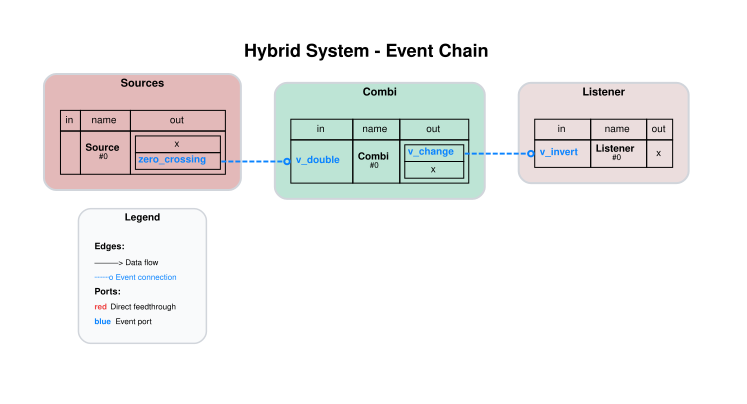


Component Classification:
 - event_sources: ['Source', 'Combi']
 - event_listeners: ['Combi', 'Listener']
 - continuous_only: []

Using Algorithm: Hybrid-Algorithm


Events detected in interval [0.30000000, 0.35000000]
Events: [('Source', 'zero_crossing')]
Located at t=(0.33333334, 0)

Handling events at (0.33333334, 0): [('Source', 'zero_crossing')]

Events grouped by component for handling: {'Combi': ['zero_crossing'], 'Listener': []}

Dispatching event 'zero_crossing' from 'Source' to targets: ['Combi']
Combi handled event at t=0.3333: v doubled from -1 to -2

New events detected after handling: [('Combi', 'v_change')]

Handling events at (0.33333334, 1): [('Combi', 'v_change')]

Events grouped by component for handling: {'Combi': [], 'Listener': ['v_change']}

Dispatching event 'v_change' from 'Combi' to targets: ['Listener']
Listener handled event at t=0.3333: v inverted from 3.0 to -3.0



In [61]:
# 1) Create components
src_comp = HybridSource(name="Source", x0=-2/3, v=2)
combi_comp = HybridCombi(name="Combi", x0=2/3,  v=-1)
listener_comp = HybridListener(name="Listener", x0=0.0,  v=3.0)

# 2) Define event indicator functions
def event_indicator_zero_crossing(comp: HybridSource) -> float:
    return comp.x
def event_indicator_v_change(comp: HybridCombi) -> float:
    return 0.0 if comp.v_curr != comp.v_prev else 1.0
    
# 3) Create events
event_1 = Event(name="zero_crossing", source=src_comp.name, direction=1)
event_2 = Event(name="v_change", source=combi_comp.name, direction=0)

# 4) Initialize event source components
src_comp.initialize(t0=0.0)
combi_comp.initialize(t0=0.0)

# 5) Add event indicators to source components
src_comp.add_event_indicator(name=event_1.name,
                               func=event_indicator_zero_crossing,
                               direction=event_1.direction)
combi_comp.add_event_indicator(name=event_2.name,
                               func=event_indicator_v_change,
                               direction=event_2.direction)

# 6) Initialize listener component and subscribe to events
combi_comp.subscribe_event(event=event_1)
listener_comp.initialize(t0=0.0)
listener_comp.subscribe_event(event=event_2)

# 7) Create system
system = System(name="Hybrid System - Event Chain")

# 8) Add components to system
system.add_component(src_comp)
system.add_component(combi_comp)
system.add_component(listener_comp)

# 9) Create and add event connections to the system
connection_1 = EventConnection(src_comp=src_comp.name,
                               src_port=src_comp.output_specs['zero_crossing'].name,
                               dst_comp=combi_comp.name,
                               dst_port=combi_comp.input_specs['v_double'].name)
connection_2 = EventConnection(src_comp=combi_comp.name,
                               src_port=combi_comp.output_specs['v_change'].name,
                               dst_comp=listener_comp.name,
                               dst_port=listener_comp.input_specs['v_invert'].name)

system.add_event_connection(connection_1)
system.add_event_connection(connection_2)
# 10) Initialize and run the system
system.initialize(t0=0.0)

# 11) Visualize the system graph
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

# 11) Component classification
print("\nComponent Classification:")
for classification, components in system.classify_components().items():
    print(f" - {classification}: {[component.name for component in components]}")

print(f"\nUsing Algorithm: {system.algorithm.name}\n")
system.run(t0=0.0, tf=1.0, dt = 0.05)


In [62]:
time_src, data_src = src_comp.get_history_arrays()
x_src = data_src['x']

time_combi, data_combi = combi_comp.get_history_arrays()
x_combi = data_combi['x']

time_listener, data_listener = listener_comp.get_history_arrays()
x_listener = data_listener['x']

event_history = system.history.get_all_event_histories()
trigger_times_1 = event_history.get((src_comp.name, 'zero_crossing'), [])
trigger_times_2 = event_history.get((combi_comp.name, 'v_change'), [])

trigger_time_1 = trigger_times_1[0].t
trigger_time_2 = trigger_times_2[0].t

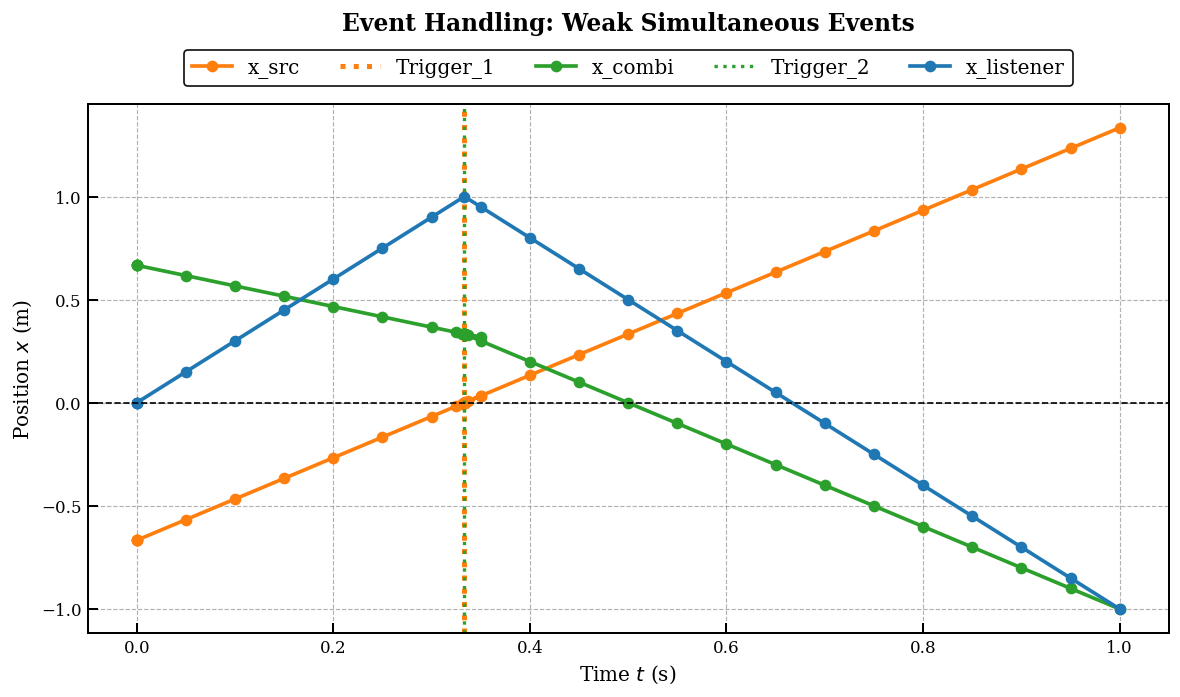

In [63]:
plt.figure(figsize=(10, 6))
plt.plot(time_src, x_src, label='x_src', color='tab:orange', marker='o', linestyle='-')
plt.axvline(trigger_time_1, color='tab:orange', linestyle=':', label='Trigger_1', linewidth=3)
plt.plot(time_combi, x_combi, label='x_combi', color='tab:green', marker='o', linestyle='-')
plt.axvline(trigger_time_2, color='tab:green', linestyle=':', label='Trigger_2', linewidth=2)
plt.plot(time_listener, x_listener, label='x_listener', color='tab:blue', marker='o', linestyle='-')
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title('Event Handling: Weak Simultaneous Events', fontsize=14, fontweight='bold', y= 1.12)
plt.xlabel('Time $t$ (s)')
plt.ylabel('Position $x$ (m)')
plt.grid()
plt.legend(loc='upper center', ncol=5, bbox_to_anchor=(0.5, 1.12))
plt.tight_layout()
plt.savefig('../figures/Hybrid/test_5_event_handling_2.svg')
plt.show()

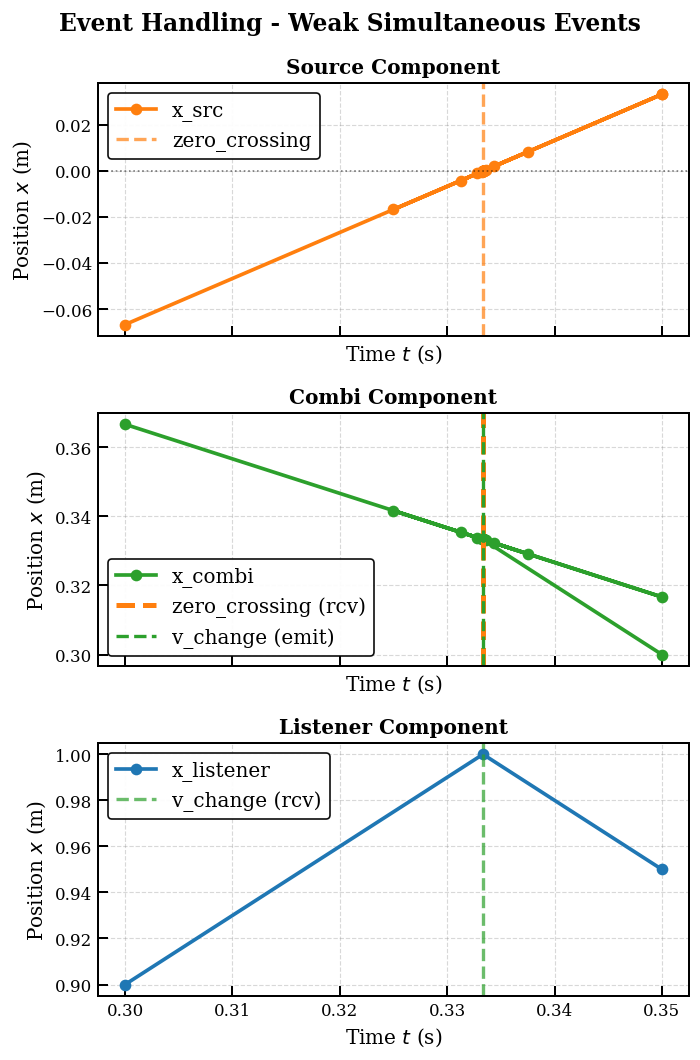

In [64]:
# Zoomed View - 3 Columns for src, combi, listener
fig, axs = plt.subplots(3, 1, figsize=(6, 9), sharex=True)

window = 0.05

# Create individual masks for each component's time array
mask_src = (time_src >= (trigger_time_1 - window)) & (time_src <= (trigger_time_1 + window))
mask_combi = (time_combi >= (trigger_time_1 - window)) & (time_combi <= (trigger_time_2 + window))
mask_listener = (time_listener >= (trigger_time_1 - window)) & (time_listener <= (trigger_time_2 + window))

# Source component - zoom around first event
axs[0].plot(time_src[mask_src], x_src[mask_src], label='x_src', color='tab:orange', marker='o', linestyle='-', markersize=6)
axs[0].axvline(trigger_time_1, color='tab:orange', linestyle='--', label='zero_crossing', linewidth=2, alpha=0.7)
axs[0].axhline(0, color='black', linestyle=':', linewidth=1, alpha=0.5)
axs[0].set_title('Source Component', fontsize=12, fontweight='bold')
axs[0].set_xlabel('Time $t$ (s)')
axs[0].set_ylabel('Position $x$ (m)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Combi component - zoom around both events
axs[1].plot(time_combi[mask_combi], x_combi[mask_combi], label='x_combi', color='tab:green', marker='o', linestyle='-', markersize=6)
axs[1].axvline(trigger_time_1, color='tab:orange', linestyle='--', label='zero_crossing (rcv)', linewidth=3)
axs[1].axvline(trigger_time_2, color='tab:green', linestyle='--', label='v_change (emit)', linewidth=2)
axs[1].set_title('Combi Component', fontsize=12, fontweight='bold')
axs[1].set_xlabel('Time $t$ (s)')
axs[1].set_ylabel('Position $x$ (m)')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

# Listener component - zoom around second event
axs[2].plot(time_listener[mask_listener], x_listener[mask_listener], label='x_listener', color='tab:blue', marker='o', linestyle='-', markersize=6)
axs[2].axvline(trigger_time_2, color='tab:green', linestyle='--', label='v_change (rcv)', linewidth=2, alpha=0.7)
axs[2].set_title('Listener Component', fontsize=12, fontweight='bold')
axs[2].set_xlabel('Time $t$ (s)')
axs[2].set_ylabel('Position $x$ (m)')
axs[2].legend()
axs[2].grid(True, alpha=0.3)

plt.suptitle('Event Handling - Weak Simultaneous Events', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/Hybrid/test_5_event_handling_2_zoomed.svg', bbox_inches='tight')
plt.show()

----------------------------------------------


## Case 3: Simultaneous Events Handling

- In this test case, we create a hybrid system where two events occur simulatneously at the same real time instant.
- We verify that the hybrid algorithm correctly detects and handles both events without conflicts by checking for commutativity of event handlers.
- Two different event sources will trigger events at the same time. Each event will trigger different event handlers that modify both the same state variable in the listener component.
- Commutativity annotations are provided to indicate that the event handlers can be applied in any order without causing conflicts.
- If no commutativity annotations are provided, the hybrid algorithm checks the affected states/outputs of each event handler to ensure commutativity.
- For dynamic commutativity checking, the components must support rollback capabilities to restore their states before handling events.

1) Identify all events that have occurred at the same real time.
2) For each event, determine the listeners and which states or outputs the event handling affects.
3) Ensure that events which occur at the same real time only affect disjoint sets of states or outputs.
4) If two or more events affect the same state or output, raise an error indicating a conflict.
5) If no conflicts are found, handle the events in any order since they affect disjoint states or outputs.

In [65]:
class HybridListener(CoSimComponent):
    """
    Simple component with a state variable that evolves linearly.
    x(t) = x0 + v * (t - t0)    
    """

    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0, use_event_annotations: bool = False):
        super().__init__(name, group="Listener")
        self.x0 = x0; self.v = v; self.t0 = t0

        if use_event_annotations:
            self.event_annotations.update({
                'v_invert': {'modifies': {'v'}, 'type': 'RMW'},
                'v_double': {'modifies': {'v'}, 'type': 'RMW'},
            })

            self.event_commutativity.update({
                ('v_invert', 'v_double'): True,
            })

        
    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

        self.input_specs.update({"v_invert": PortSpec(name="v_invert", type=PortType.EVENT, direction="in"),  
                                 "v_double": PortSpec(name="v_double", type=PortType.EVENT, direction="in")})  
        self.output_specs.update({"x": PortSpec(name="x", type=PortType.REAL, direction="out"),
                                  'v': PortSpec(name="v", type=PortType.REAL, direction="out")})

        self._initialize_ports_from_specs()
        
    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)
        
    def _update_output_states(self, t: Optional[float]=None, event_names: Optional[list]=None) -> None:
        self.outputs["x"].set(self.x, t=t)
        self.outputs["v"].set(self.v, t=t)
        
    def set_state(self, state: Dict[str, Any], t: float) -> None:
        if "x" in state:
            val = state["x"]
            self.x = val.magnitude if isinstance(val, Quantity) else val
        if "v" in state:
            val = state["v"]
            self.v = val.magnitude if isinstance(val, Quantity) else val
            
    def get_state(self) -> Dict[str, Any]:
        return {"x": self.x, 'v': self.v}
    

    def snapshot_state(self):
        state = {
            "t": self.t,
            "x": self.x,
            "v": self.v,
            "t0": self.t0
        }
        return state
    
    def restore_state(self, snapshot, t):
        self.t = snapshot["t"]
        self.t0 = snapshot["t0"]
        self.x = snapshot["x"]
        self.v = snapshot["v"]

    def _handle_events_internal(self, event_names, t):
        if 'v_invert' in event_names:
            self.t0 = t
            self.x0 = self.x
            self.v = -self.v
            print(f"{self.name} handled 'v_invert' event at t={t:.4f}: v_prev = { -self.v }, v_curr = { self.v }")
        if 'v_double' in event_names:
            self.t0 = t
            self.x0 = self.x
            self.v = 2 * self.v
            print(f"{self.name} handled 'v_double' event at t={t:.4f}: v_prev = { self.v / 2 }, v_curr = { self.v }")
    
    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self._t0 = None
        self.inputs = {}
        self.outputs = {}

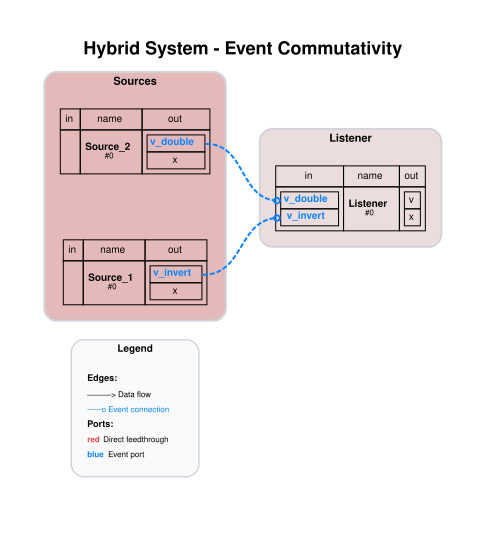


Component Classification:
 - event_sources: ['Source_1', 'Source_2']
 - event_listeners: ['Listener']
 - continuous_only: []

Using Algorithm: Hybrid-Algorithm

Starting hybrid co-simulation...


Events detected in interval [0.65000000, 0.70000000]
Events: [('Source_1', 'v_invert'), ('Source_2', 'v_double')]
Located at t=(0.66666667, 0)

Handling events at (0.66666667, 0): [('Source_1', 'v_invert'), ('Source_2', 'v_double')]

Events grouped by component for handling: {'Listener': ['v_invert', 'v_double']}

Checking commutativity for events ['v_invert', 'v_double'] on component Listener...
Verifying dynamically ...
Listener handled 'v_invert' event at t=0.6667: v_prev = 3.0, v_curr = -3.0
Listener handled 'v_double' event at t=0.6667: v_prev = -3.0, v_curr = -6.0
Listener handled 'v_double' event at t=0.6667: v_prev = 3.0, v_curr = 6.0
Listener handled 'v_invert' event at t=0.6667: v_prev = 6.0, v_curr = -6.0
Event handlers ['v_invert', 'v_double'] on component Listener verified as com

In [66]:
# 1) Create components
src_comp_1 = HybridSource(name="Source_1", x0=2/3, v=-1)
src_comp_2 = HybridSource(name="Source_2", x0=-2/3, v=1)
listener_comp = HybridListener(name="Listener", x0=0.0, v=3.0)

# 2) Define event indicator functions
def event_indicator_zero_crossing(comp: HybridSource) -> float:
    return comp.x
    
# 3) Create events
event_1 = Event(name="v_invert", source=src_comp_1.name, direction=-1)
event_2 = Event(name="v_double", source=src_comp_2.name, direction=1)

# 4) Initialize event source components
src_comp_1.initialize(t0=0.0)
src_comp_2.initialize(t0=0.0)

# 5) Add event indicators to source components
src_comp_1.add_event_indicator(name=event_1.name,
                               func=event_indicator_zero_crossing,
                               direction=event_1.direction)
src_comp_2.add_event_indicator(name=event_2.name,
                               func=event_indicator_zero_crossing,
                               direction=event_2.direction)

# 6) Initialize listener component and subscribe to events
listener_comp.initialize(t0=0.0)
listener_comp.subscribe_event(event=event_1)
listener_comp.subscribe_event(event=event_2)

# 7) Create system
system = System(name="Hybrid System - Event Commutativity")

# 8) Add components to system
system.add_component(src_comp_1)
system.add_component(src_comp_2)
system.add_component(listener_comp)

# 9) Create and add event connections to the system
connection_1 = EventConnection(src_comp=src_comp_1.name,
                               src_port=src_comp_1.output_specs['v_invert'].name,
                               dst_comp=listener_comp.name,
                               dst_port=listener_comp.input_specs['v_invert'].name)
connection_2 = EventConnection(src_comp=src_comp_2.name,
                               src_port=src_comp_2.output_specs['v_double'].name,
                               dst_comp=listener_comp.name,
                               dst_port=listener_comp.input_specs['v_double'].name)
system.add_event_connection(connection_1)
system.add_event_connection(connection_2)

# 10) Initialize the system
system.initialize(t0=0.0)

# 12) Visualize the system graph
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

# 11) Component classification
print("\nComponent Classification:")
for classification, components in system.classify_components().items():
    print(f" - {classification}: {[component.name for component in components]}")
print(f"\nUsing Algorithm: {system.algorithm.name}\n")

# 13) Run the simulation
print("Starting hybrid co-simulation...\n")
system.run(t0=0.0, tf=1.0, dt = 0.05)


In [67]:
time_src_1, data_src_1 = src_comp_1.get_history_arrays()
x_src_1 = data_src_1['x']

time_src_2, data_src_2 = src_comp_2.get_history_arrays()
x_src_2 = data_src_2['x']

time_listener, data_listener = listener_comp.get_history_arrays()
x_listener = data_listener['x']

event_history = system.history.get_all_event_histories()
trigger_times_1 = event_history.get((src_comp_1.name, 'v_invert'), [])
trigger_times_2 = event_history.get((src_comp_2.name, 'v_double'), [])

trigger_time_1 = trigger_times_1[0].t
trigger_time_2 = trigger_times_2[0].t

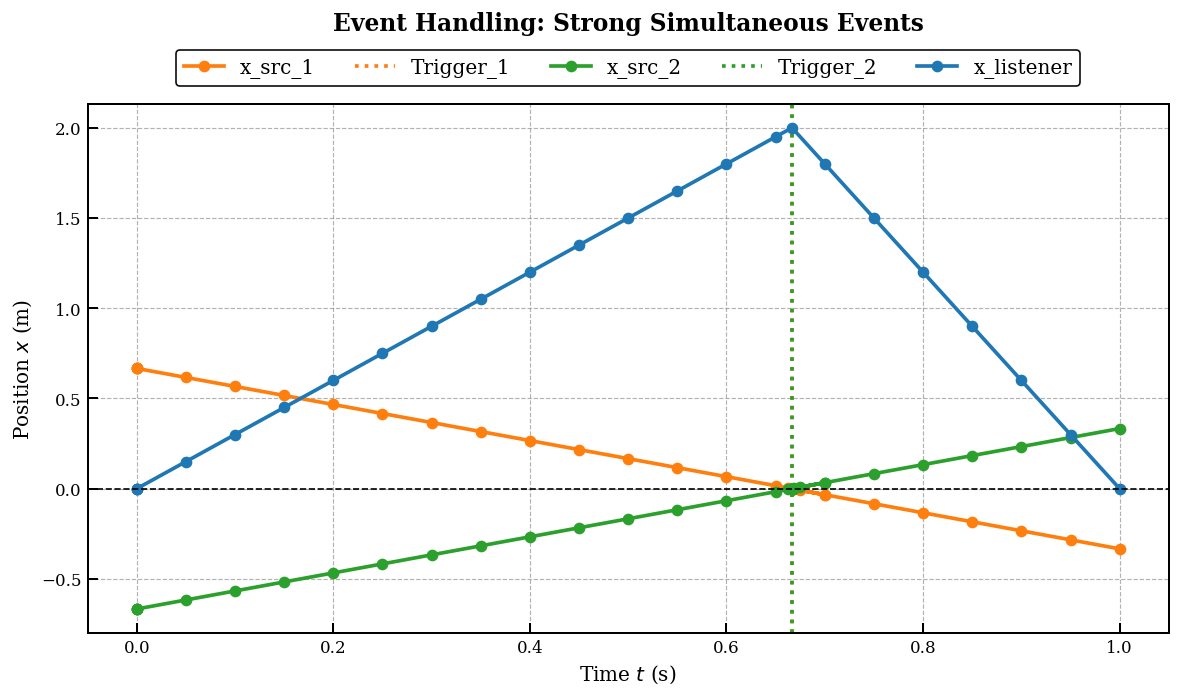

In [68]:
plt.figure(figsize=(10, 6))
plt.plot(time_src_1, x_src_1, label='x_src_1', color='tab:orange', marker='o', linestyle='-')
plt.axvline(trigger_time_1, color='tab:orange', linestyle=':', label='Trigger_1')
plt.plot(time_src_2, x_src_2, label='x_src_2', color='tab:green', marker='o', linestyle='-')
plt.axvline(trigger_time_2, color='tab:green', linestyle=':', label='Trigger_2')
plt.plot(time_listener, x_listener, label='x_listener', color='tab:blue', marker='o', linestyle='-')
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title('Event Handling: Strong Simultaneous Events', fontsize=14, fontweight='bold', y= 1.12)
plt.xlabel('Time $t$ (s)')
plt.ylabel('Position $x$ (m)')
plt.grid()
plt.legend(loc='upper center', ncol=5, bbox_to_anchor=(0.5, 1.12))
plt.tight_layout()
plt.savefig('../figures/Hybrid/test_5_event_handling_3.svg')
plt.show()